In [1]:
# https://drive.google.com/file/d/1IHoMOnmA_TUGwBoUlQIAwb8nokqs5at8/view?usp=sharing

In [2]:
pip install gdown

In [3]:
# Download the zip file from Google Drive
import gdown
import os

# link: https://drive.google.com/file/d/1xNDwcGyhqY_7tdVc58YSJCS4DptDoEUL/view?usp=sharing
file_id = '1xNDwcGyhqY_7tdVc58YSJCS4DptDoEUL'
output_filename = 'archive.zip'

gdown.download(id=file_id, output=output_filename, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1xNDwcGyhqY_7tdVc58YSJCS4DptDoEUL
From (redirected): https://drive.google.com/uc?id=1xNDwcGyhqY_7tdVc58YSJCS4DptDoEUL&confirm=t&uuid=6eb893fe-1a8a-4a2c-bcfd-2ace29f80711
To: /content/archive.zip
100%|██████████| 1.27G/1.27G [00:16<00:00, 76.8MB/s]


'archive.zip'

In [4]:
# Extract the contents of the zip file
import zipfile

if os.path.exists(output_filename):
    with zipfile.ZipFile(output_filename, 'r') as zip_ref:
        zip_ref.extractall('.') # Extract to the current directory
    print(f"Successfully extracted '{output_filename}'")
    # Optionally, remove the zip file after extraction
    # os.remove(output_filename)
else:
    print(f"Error: The file '{output_filename}' was not found.")

Successfully extracted 'archive.zip'


In [5]:
# List the contents of the current directory to see extracted files
print("Contents of the current directory after extraction:")
print(os.listdir('.'))

Contents of the current directory after extraction:
['.config', 'train', 'archive.zip', 'test', 'sample_data']


splitting data

In [6]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transformation

In [7]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.Resize((110, 100)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

full_dataset = datasets.ImageFolder(root='train', transform=transform)

In [8]:
# Split the full_dataset into training and validation sets
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

In [9]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [10]:
num_classes = len(full_dataset.classes)
print(f"Number of classes in the dataset: {num_classes}")

Number of classes in the dataset: 4


In [11]:
from collections import Counter

# Count classes in train_dataset
train_class_counts = Counter()
for _, labels in train_loader:
    train_class_counts.update(labels.cpu().numpy())

print("Number of images per class in Training Set:")
for class_idx, count in sorted(train_class_counts.items()):
    class_name = full_dataset.classes[class_idx]
    print(f"  Class {class_name} (ID: {class_idx}): {count} images")

# Count classes in val_dataset
val_class_counts = Counter()
for _, labels in val_loader:
    val_class_counts.update(labels.cpu().numpy())

print("\nNumber of images per class in Validation Set:")
for class_idx, count in sorted(val_class_counts.items()):
    class_name = full_dataset.classes[class_idx]
    print(f"  Class {class_name} (ID: {class_idx}): {count} images")

Number of images per class in Training Set:
  Class broadleaf (ID: 0): 682 images
  Class grass (ID: 1): 1972 images
  Class soil (ID: 2): 1827 images
  Class soybean (ID: 3): 4106 images

Number of images per class in Validation Set:
  Class broadleaf (ID: 0): 151 images
  Class grass (ID: 1): 492 images
  Class soil (ID: 2): 447 images
  Class soybean (ID: 3): 1057 images


MobilenetV2

In [13]:
from torchvision import models
import torch.nn as nn

model = models.resnet50(pretrained=True)

# Freeze layers
for param in model.parameters():
    param.requires_grad = False

# Replace final layer
model.fc = nn.Sequential(
    nn.Linear(2048, 128),
    nn.ReLU(),

    nn.Linear(128, 4)
)

# model = model.to("cuda")

Training loop

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.00001)

In [15]:
import torch
from sklearn.metrics import f1_score, precision_score, recall_score

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(10):
    # ---- TRAIN ----
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.cuda(), labels.cuda()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(correct / total)

    # ---- VALIDATION ----
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.cuda(), labels.cuda()

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(correct / total)

    # ---- F1, Precision, Recall ----
    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracies[-1]:.4f}")
    print(f"Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accuracies[-1]:.4f}")
    print(f"F1: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")
    print("-"*40)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 1
Train Loss: 1.1214, Train Acc: 0.5039
Val Loss: 0.9352, Val Acc: 0.6274
F1: 0.5383, Precision: 0.7004, Recall: 0.6274
----------------------------------------
Epoch 2
Train Loss: 0.8431, Train Acc: 0.7268
Val Loss: 0.7113, Val Acc: 0.8188
F1: 0.7859, Precision: 0.8483, Recall: 0.8188
----------------------------------------
Epoch 3
Train Loss: 0.6527, Train Acc: 0.8476
Val Loss: 0.5623, Val Acc: 0.8859
F1: 0.8667, Precision: 0.8937, Recall: 0.8859
----------------------------------------
Epoch 4
Train Loss: 0.5278, Train Acc: 0.8936
Val Loss: 0.4571, Val Acc: 0.9222
F1: 0.9167, Precision: 0.9248, Recall: 0.9222
----------------------------------------
Epoch 5
Train Loss: 0.4356, Train Acc: 0.9200
Val Loss: 0.3858, Val Acc: 0.9381
F1: 0.9361, Precision: 0.9388, Recall: 0.9381
----------------------------------------
Epoch 6
Train Loss: 0.3764, Train Acc: 0.9298
Val Loss: 0.3399, Val Acc: 0.9427
F1: 0.9414, Precision: 0.9433, Recall: 0.9427
---------------------------------------

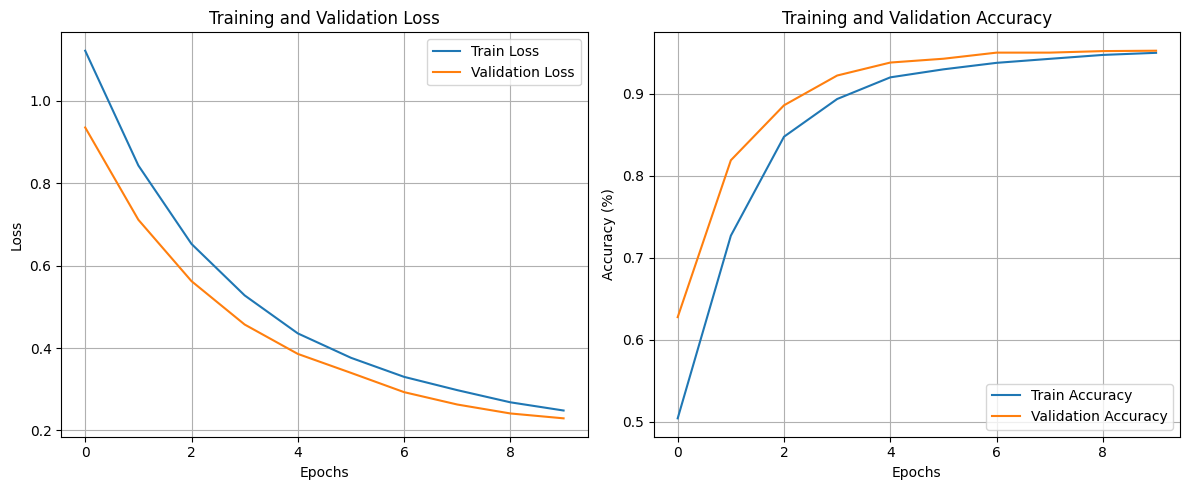

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)



plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot

plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
f1 = f1_score(all_labels, all_preds, average='weighted')
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')

print("Final Results:")
print("F1 Score:", f1)
print("Precision:", precision)
print("Recall:", recall)

Final Results:
F1 Score: 0.9517388445757616
Precision: 0.9529933373138288
Recall: 0.952491849091756


In [18]:
total_params = sum(p.numel() for p in model.parameters())
print("Total parameters:", total_params)

Total parameters: 23770820


Evaluation on Test Data

In [19]:
test_dataset = datasets.ImageFolder(root='test', transform=transform)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)

# Count classes in test_dataset
test_class_counts = Counter()
for _, labels in test_loader:
    test_class_counts.update(labels.cpu().numpy())

print("Number of images per class in Test Set:")
for class_idx, count in sorted(test_class_counts.items()):
    class_name = full_dataset.classes[class_idx]
    print(f"  Class {class_name} (ID: {class_idx}): {count} images")

Number of images per class in Test Set:
  Class broadleaf (ID: 0): 358 images
  Class grass (ID: 1): 1056 images
  Class soil (ID: 2): 975 images
  Class soybean (ID: 3): 2213 images


In [20]:
def evaluate_model(model, test_loader):
    model.eval()

    test_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total

    print(f"Test Loss: {test_loss/len(test_loader):.4f}")
    print(f"Test Accuracy: {accuracy:.2f}%")

    return all_preds, all_labels

In [21]:
preds, labels = evaluate_model(model, test_loader)

Test Loss: 0.2424
Test Accuracy: 94.46%


In [22]:
from sklearn.metrics import classification_report

print(classification_report(labels, preds, target_names=test_dataset.classes))

              precision    recall  f1-score   support

   broadleaf       0.92      0.78      0.85       358
       grass       0.90      0.93      0.91      1056
        soil       0.97      0.96      0.96       975
     soybean       0.96      0.98      0.97      2213

    accuracy                           0.94      4602
   macro avg       0.94      0.91      0.92      4602
weighted avg       0.94      0.94      0.94      4602

